In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Read data
df = pd.read_csv(r"E:\Self Learning\Datasets Collection\Transjakarta - Public Transportation Transaction\dfTransjakarta.csv")

Data Understanding

In [4]:
df.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0


In [5]:
# Check null value and remove if it exists
def checkNull(data):
    if data.isna().sum().any():
        print('Null value detected and removed')
        data.dropna(inplace=True)
    else:
        print('No null value detected')

checkNull(df)

Null value detected and removed


In [6]:
# Check null value
df.isna().sum()

transID             0
payCardID           0
payCardBank         0
payCardName         0
payCardSex          0
payCardBirthDate    0
corridorID          0
corridorName        0
direction           0
tapInStops          0
tapInStopsName      0
tapInStopsLat       0
tapInStopsLon       0
stopStartSeq        0
tapInTime           0
tapOutStops         0
tapOutStopsName     0
tapOutStopsLat      0
tapOutStopsLon      0
stopEndSeq          0
tapOutTime          0
payAmount           0
dtype: int64

In [7]:
# Check data information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185693 entries, 0 to 227399
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transID           185693 non-null  object 
 1   payCardID         185693 non-null  int64  
 2   payCardBank       185693 non-null  object 
 3   payCardName       185693 non-null  object 
 4   payCardSex        185693 non-null  object 
 5   payCardBirthDate  185693 non-null  int64  
 6   corridorID        185693 non-null  object 
 7   corridorName      185693 non-null  object 
 8   direction         185693 non-null  float64
 9   tapInStops        185693 non-null  object 
 10  tapInStopsName    185693 non-null  object 
 11  tapInStopsLat     185693 non-null  float64
 12  tapInStopsLon     185693 non-null  float64
 13  stopStartSeq      185693 non-null  int64  
 14  tapInTime         185693 non-null  object 
 15  tapOutStops       185693 non-null  object 
 16  tapOutStopsName   185693 

In [8]:
# Convert time stamp data to date time
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185693 entries, 0 to 227399
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transID           185693 non-null  object        
 1   payCardID         185693 non-null  int64         
 2   payCardBank       185693 non-null  object        
 3   payCardName       185693 non-null  object        
 4   payCardSex        185693 non-null  object        
 5   payCardBirthDate  185693 non-null  int64         
 6   corridorID        185693 non-null  object        
 7   corridorName      185693 non-null  object        
 8   direction         185693 non-null  float64       
 9   tapInStops        185693 non-null  object        
 10  tapInStopsName    185693 non-null  object        
 11  tapInStopsLat     185693 non-null  float64       
 12  tapInStopsLon     185693 non-null  float64       
 13  stopStartSeq      185693 non-null  int64         
 14  tapInTime

In [10]:
df.describe()

,payCardID,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
count,1.856930e+05,185693.000000,185693.000000,185693.000000,185693.000000,185693.000000,185693,185693.000000,185693.000000,185693.000000,185693,185693.000000
mean,3.994253e+17,1990.155310,0.499631,-6.213828,106.841509,13.518350,2023-04-16 07:48:42.770734848,-6.213714,106.841055,21.117382,2023-04-16 09:00:52.126337536,2683.022516
min,6.040368e+10,1946.000000,0.000000,-6.394973,106.614730,0.000000,2023-04-01 05:14:35,-6.394973,106.614730,1.000000,2023-04-01 06:04:48,0.000000
25%,1.800124e+14,1982.000000,0.000000,-6.246264,106.800980,4.000000,2023-04-10 08:49:23,-6.246510,106.800810,11.000000,2023-04-10 09:58:48,0.000000
50%,3.518481e+15,1991.000000,0.000000,-6.213433,106.836790,10.000000,2023-04-16 17:03:53,-6.213275,106.835420,18.000000,2023-04-16 18:19:50,3500.000000
75%,4.677309e+15,2001.000000,1.000000,-6.173818,106.882700,20.000000,2023-04-21 21:49:37,-6.172372,106.882950,29.000000,2023-04-21 23:25:06,3500.000000
max,4.999814e+18,2012.000000,1.000000,-6.089429,107.023950,75.000000,2023-04-30 21:58:17,-6.089429,107.023840,77.000000,2023-04-30 23:49:48,20000.000000
std,1.280903e+18,13.371894,0.500001,0.058664,0.061153,12.214717,NaN,0.059735,0.061871,13.981316,NaN,4156.264771


Exploratory Data Analysis

In [11]:
df_eda = df.copy()

Customer Age Distribution Analysis

In [12]:
# Calculate customer ages as of 2023
df_eda['custAge'] = 2023 - df_eda['payCardBirthDate']

In [13]:
# Group customer ages into intervals
custAge = df_eda['custAge'].copy()

bins = [10, 20, 31, 40, 50, 60, 70, 80]
labels = ['10-19','20-29','30-39','40-49','50-59','60-69','70+']
custAge['ageRange'] = pd.cut(df_eda['custAge'], bins=bins, labels=labels, include_lowest=True)

custAgeCount = custAge['ageRange'].value_counts().reset_index(name='count')

custAgeCount

,custAge,count
0,30-39,49615
1,20-29,48735
2,10-19,39564
3,40-49,26663
4,50-59,16808
5,60-69,2424
6,70+,1884


In [14]:
# Create a bar plot of the age distribution
def ageDist(data, agerange_col, count_col):
    dataSort = data.sort_values(by=agerange_col)
    ax = dataSort.plot(x=agerange_col, y=count_col, kind='bar', legend=False)

    for x, val in enumerate(dataSort[count_col]):
        ax.text(x, val, str(val), ha='center', va='bottom')

    plt.title('Customer Age Distribution')
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.show()

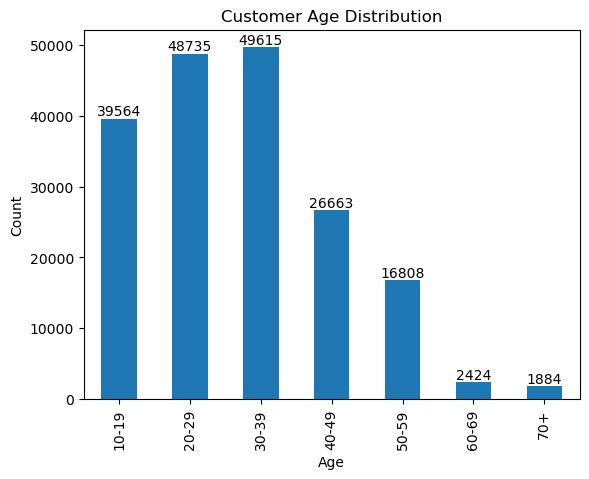

In [15]:
# Show customer age distribution
ageDist(custAgeCount, 'custAge', 'count')

The majority of Transjakarta users are concentrated in the productive age groups, especially those aged 20–39, which form the largest share of trips. This indicates that the service is heavily used by students and working-age adults. Usage declines gradually in the 40–59 age range and drops sharply among seniors aged 60 and above, suggesting lower reliance on Transjakarta among older populations.

Customer Gender Distribution Analysis

In [16]:
# Create a pie chart of the gender distribution
def GenderDist(data, gender):
    counts = data[gender].value_counts()
    plt.pie(counts.values, labels=counts.index, autopct= '%1.1f%%')
    plt.title('Gender Distribution')
    plt.axis('equal')
    plt.show()

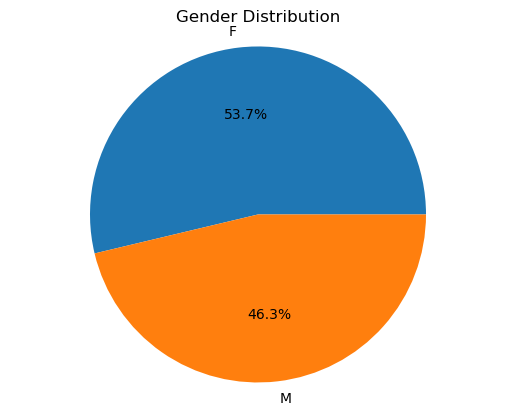

In [17]:
# Show customer gender distribution
GenderDist(df_eda, 'payCardSex')

The gender composition of Transjakarta users is relatively balanced, with female riders making up a slightly larger share (53.8%) compared to male riders (46.2%). This indicates that the service is widely used by both genders, with a modest predominance of women in overall trip activity.

Customer Payment Analysis

In [18]:
# Create a count plot of customers' paycard banks
def showCountPay(data, paycard):
    sns.countplot(x=paycard, data=data)
    plt.title(f'Distribution of {paycard}')
    plt.xlabel(f'{paycard}')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

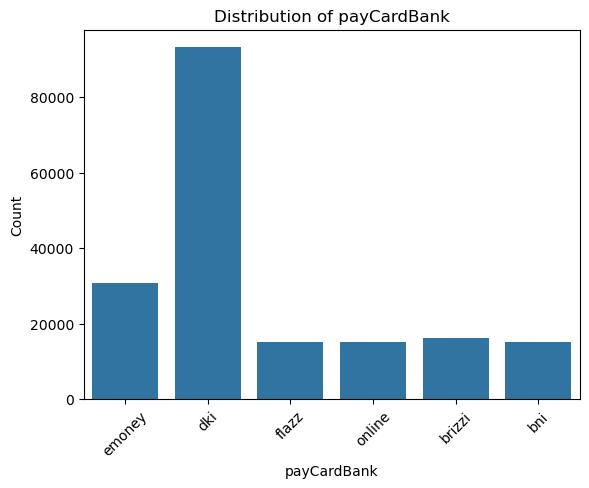

In [19]:
# Show paycard bank distribution
showCountPay(df_eda, 'payCardBank')

The bar chart shows the distribution of users across different payCardBank options. DKI is the most used with about 78,000 users, followed by Emoney with around 25,000. BNI, Brizzi, Flazz, and Online have similar usage, each with roughly 12,000 to 13,500 users. This shows a clear preference for DKI while the other options have smaller user bases.

In [20]:
# Create a histogram of customers' payment amount
def histAmount(data, col):
    sns.histplot(data, x=col, kde=True)
    plt.title('Distribution of Payment Amounts')
    plt.xlabel('Payment Amount')
    plt.ylabel('Count')
    plt.show()
    avg_payment = data[col].mean()
    max_payment = data[col].max()
    min_payment = data[col].min()
    print(f'Average Payment: {avg_payment}')
    print(f'Max Payment: {max_payment}')
    print(f'Min Payment: {min_payment}')

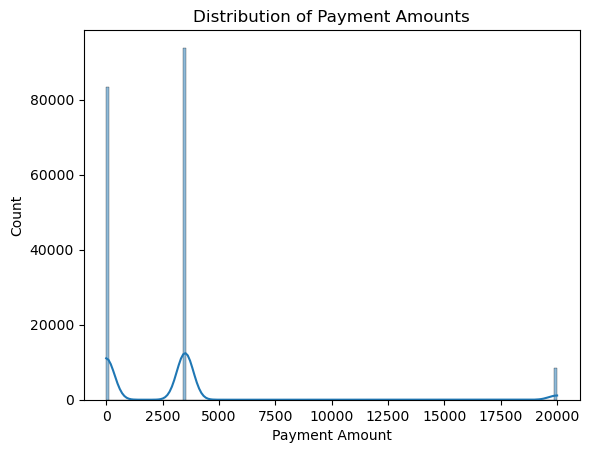

Average Payment: 2683.022515657564
Max Payment: 20000.0
Min Payment: 0.0


In [21]:
# Show payment amounts distribution
histAmount(df_eda, 'payAmount')

The chart shows the distribution of payment amounts across different levels. The amount around 3,500 is the most frequent with about 78,000 occurrences, followed by payments near 0 with around 70,000. The maximum payment of 20,000 has a much lower count of roughly 7,500. This shows that most users pay either a specific mid-range amount or nothing at all, while the highest price point is rarely used.

Rush Hour Analysis

In [22]:
# Extract hours and days from tapInTime and TapOutTime
df_eda['tapInHour'] = df_eda['tapInTime'].dt.hour
df_eda['tapOutHour'] = df_eda['tapOutTime'].dt.hour
df_eda['tapDay'] = df_eda['tapInTime'].dt.dayofweek

# Calculate travel duration in minutes
df_eda['travelDuration'] = df_eda['tapOutTime'] - df_eda['tapInTime']
df_eda['travelDuration'] = df_eda['travelDuration'].dt.total_seconds()/60

In [23]:
# Group by tapInHour/tapOutHours and count trips
def tapPerHour(data, by: str):
    result = data.groupby(by)['transID'].count()
    return result

# Calculate total tapInHour and tapOutHour activities per hour
def countHours(tapIn, tapOut):
    tap_counts = tapIn.add(tapOut, fill_value = 0)
    return tap_counts

totalTap = countHours(tapPerHour(df_eda, 'tapInHour'), tapPerHour(df_eda, 'tapOutHour'))

In [24]:
# Create a bar plot of rush hour distribution
def rushHour(data):
    sns.barplot(x=data.index, y=totalTap.values, hue= data.values, palette='RdYlGn_r', legend=False)
    plt.title('Rush Hour Distribution')
    plt.xlabel('Hour')
    plt.ylabel('Number of Trips')
    plt.show()

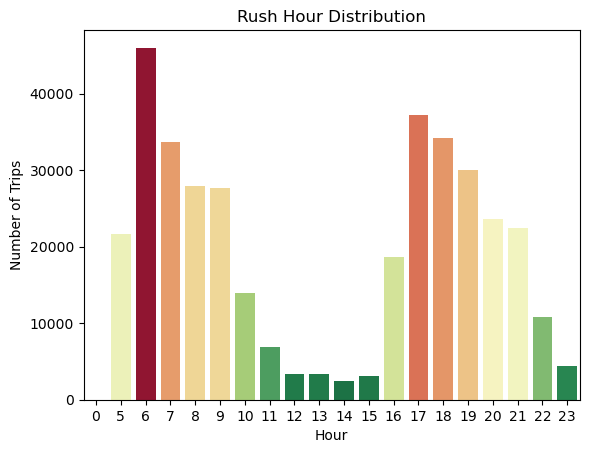

In [25]:
# Show rush hour distribution
rushHour(totalTap)

The bar chart shows the distribution of trips across different hours of the day. Hour 6 is the most busy with about 38,000 trips, followed by Hour 17 with around 31,000. Hours 7, 18, and 19 also show high usage, each with roughly 25,000 to 28,500 trips. This indicates clear morning and evening peaks, while the middle of the day between Hours 12 and 15 sees the lowest activity with only about 2,000 to 3,000 trips.

Average, Maximum, and Minimum Travel Durations

In [26]:
# Calculate the average, maximum, and minimum of travel durations
def weekData(trv_dur, central):
    if central == 'mean':
        duration = df_eda[trv_dur].mean()
        day_duration = df_eda.groupby('tapDay')[trv_dur].mean()
    elif central == 'max':
        duration = df_eda[trv_dur].max()
        day_duration = df_eda.groupby('tapDay')[trv_dur].max()
    else:
        duration = df_eda[trv_dur].min()
        day_duration = df_eda.groupby('tapDay')[trv_dur].min()
    return day_duration

In [27]:
# Create a bar plot of average, maximum, or minimum travel durations
def showWeekData(data, title: str):
    sns.barplot(x=data.index, y=data.values)
    plt.title(title)
    plt.xlabel('Day')
    plt.ylabel('Duration')
    plt.show()

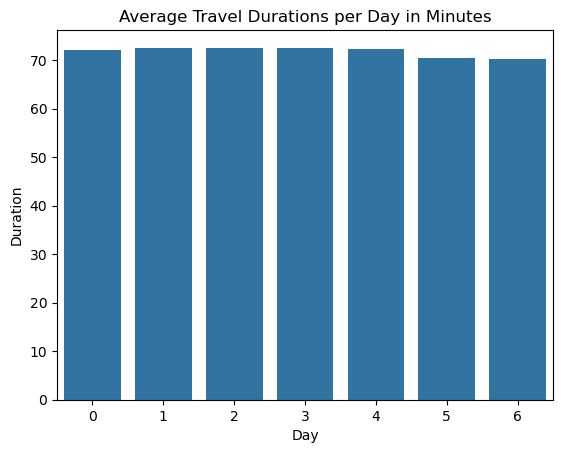

In [28]:
# Show average travel durations per day in minutes
showWeekData(weekData('travelDuration', 'mean'), 'Average Travel Durations per Day in Minutes')

The Average Travel Durations chart displays how long trips last across different days of the week. Travel times are very consistent, staying around 70 to 72 minutes every day. Days 1 through 4 show slightly higher averages at roughly 72 minutes, while Days 5 and 6 are slightly lower at about 70 minutes. This indicates that while the number of trips changes by hour, the actual time spent traveling remains stable throughout the week.

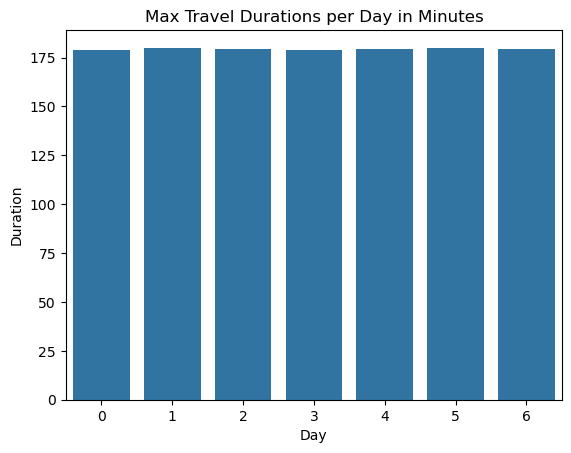

In [29]:
# Show max travel durations per day in minutes
showWeekData(weekData('travelDuration', 'max'), 'Max Travel Durations per Day in Minutes')

The Max Travel Durations chart shows the longest trips recorded each day. These maximums are also very stable, consistently reaching about 180 minutes (3 hours) across all seven days. This shows that while trip volume changes significantly by the hour, the maximum travel times remain nearly constant throughout the week.

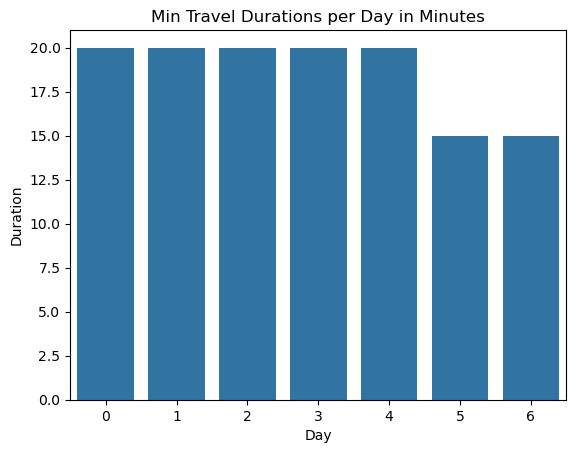

In [30]:
# Show min travel durations per day in minutes
showWeekData(weekData('travelDuration', 'min'), 'Min Travel Durations per Day in Minutes')

The Min Travel Durations chart shows the shortest trips recorded each day. For Days 0 through 4, the shortest trips are consistently 20 minutes. On Days 5 and 6, the minimum trip duration drops slightly to 15 minutes. This shows that while peak trip volume and average times are very stable, the shortest possible trips vary slightly depending on the day of the week.

Min vs Max Travel Time by Corridor Analysis

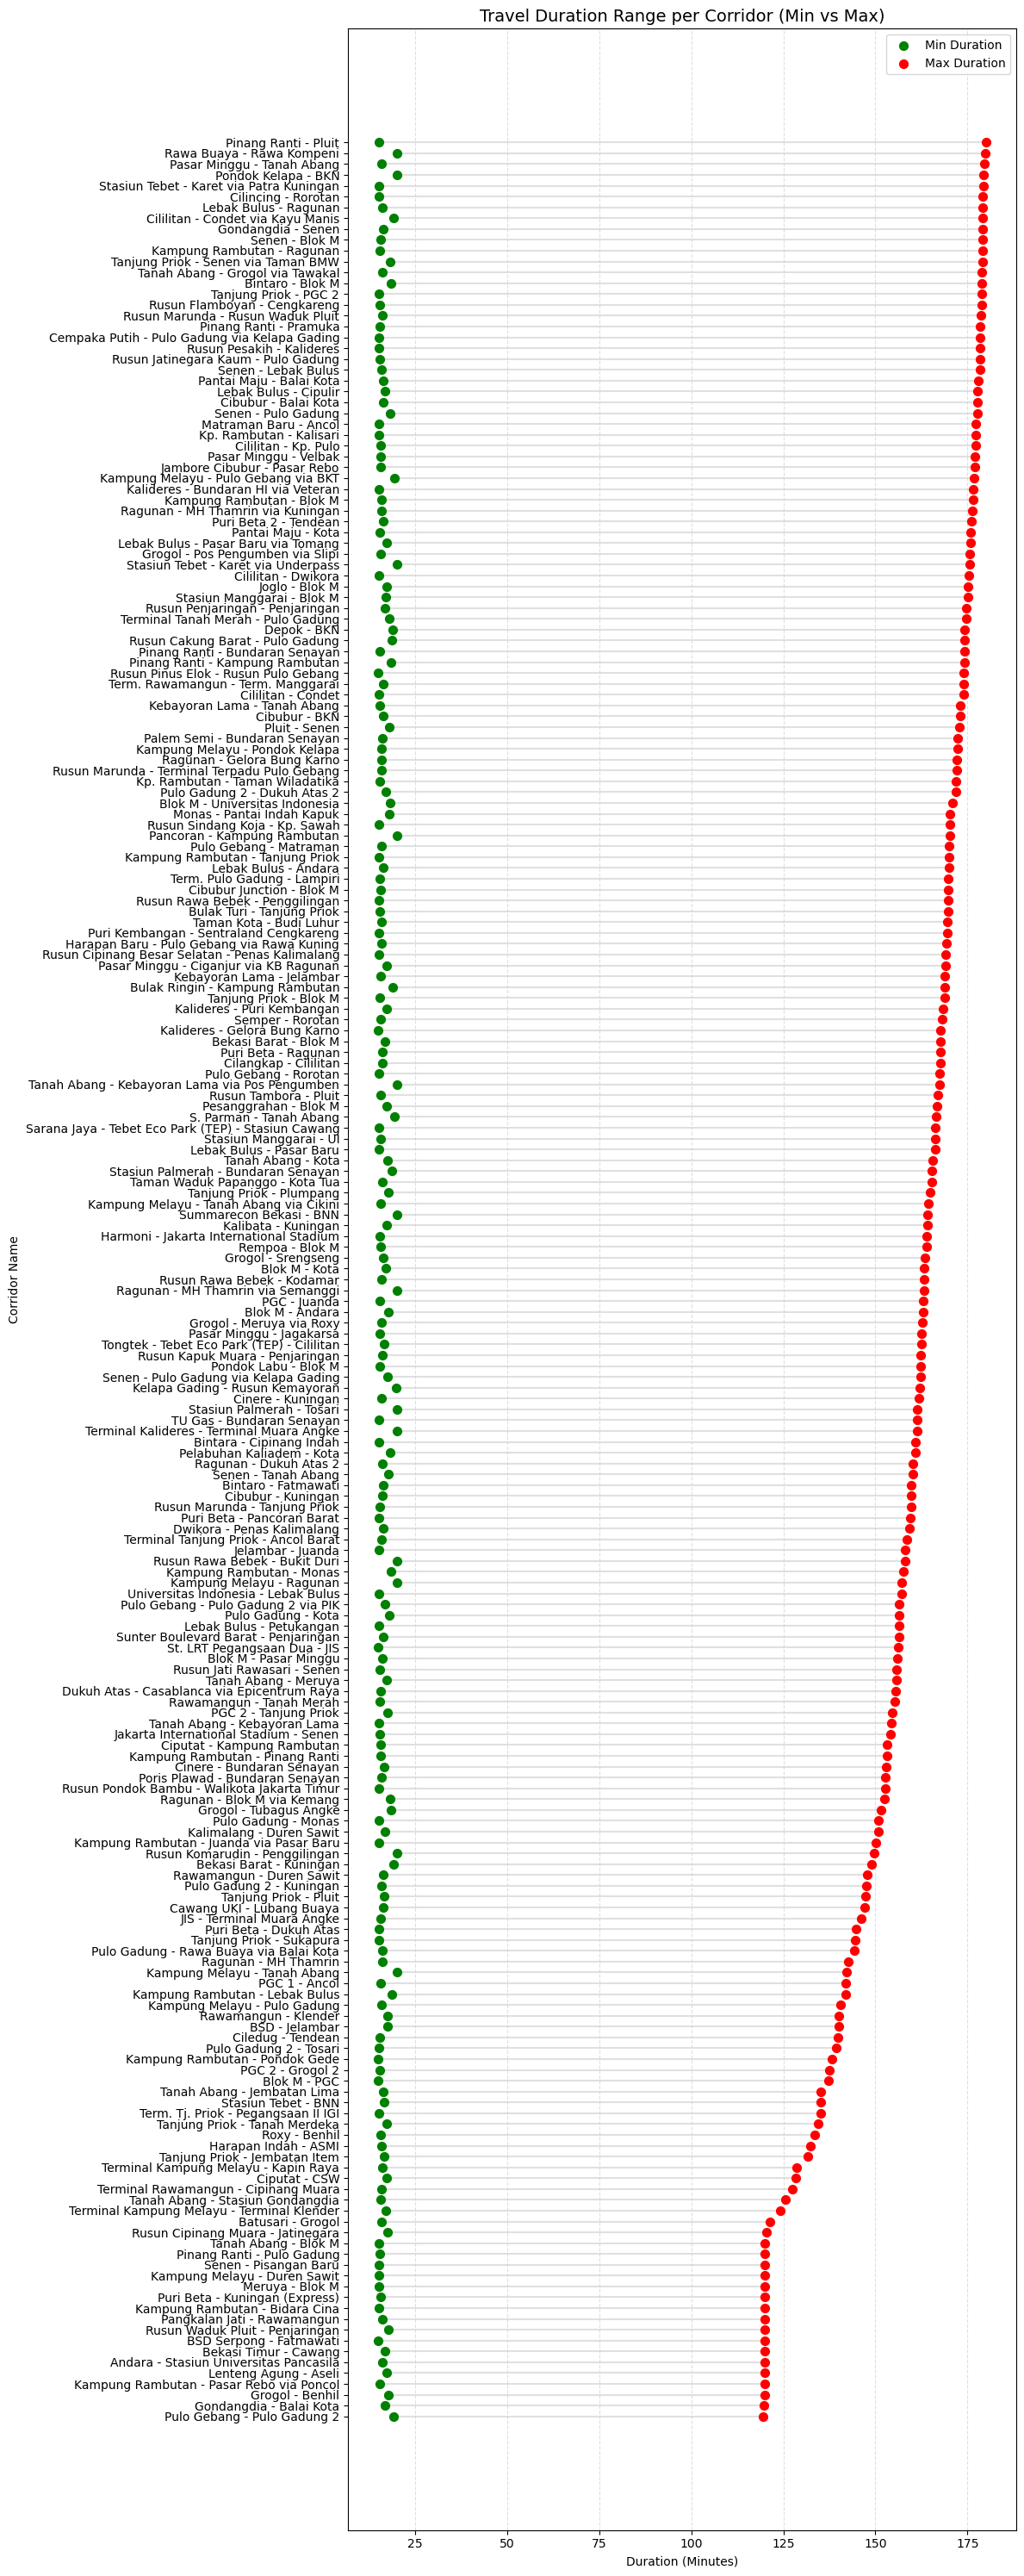

In [31]:
# Calculate max and min travel time by corridor
stats = df_eda.groupby('corridorName')['travelDuration'].agg(['min', 'max']).reset_index()
stats = stats.sort_values('max', ascending=True)

# Create a dumbbel plot to show travel duration range per corridor
plt.figure(figsize=(12, 30))
plt.hlines(y=stats['corridorName'], xmin=stats['min'], xmax=stats['max'], color='lightgrey', lw=1.5, alpha=0.7)
plt.scatter(stats['min'], stats['corridorName'], color='green', label='Min Duration', s=50, zorder=3)
plt.scatter(stats['max'], stats['corridorName'], color='red', label='Max Duration', s=50, zorder=3)

plt.title('Travel Duration Range per Corridor (Min vs Max)', fontsize=14)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Corridor Name')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

This chart shows the range of travel times for each route, comparing the fastest possible trip to the absolute slowest recorded. The green dots represent the best-case scenarios where everything goes smoothly, while the red dots show the longest journeys. Noticeably, the slowest trips all stop at the exact same point across every single route. This suggests that the data isn't just showing traffic, but likely a system time limit that automatically cuts off a trip after it hits a certain number of minutes. Because of this, there is a massive gap between the best and worst times, making the travel duration for these corridors look very inconsistent.

Top 5 Tap In and Tap Out Stations

In [32]:
# Count taps by tap-in or tap-out stop name
def topStop(data, stopname_col):
    tapStation = data[stopname_col].value_counts().reset_index(name='transaction')

    ax = sns.barplot(x=stopname_col, y='transaction', data=tapStation.head(5))

    for x, val in enumerate(tapStation.head(5)['transaction']):
        ax.text(x, val, str(val), ha='center', va='bottom')

    plt.title(f'Top 5 {stopname_col}')
    plt.xlabel('Stops Name')
    plt.ylabel('Taps')
    plt.xticks(rotation=30)
    plt.show()

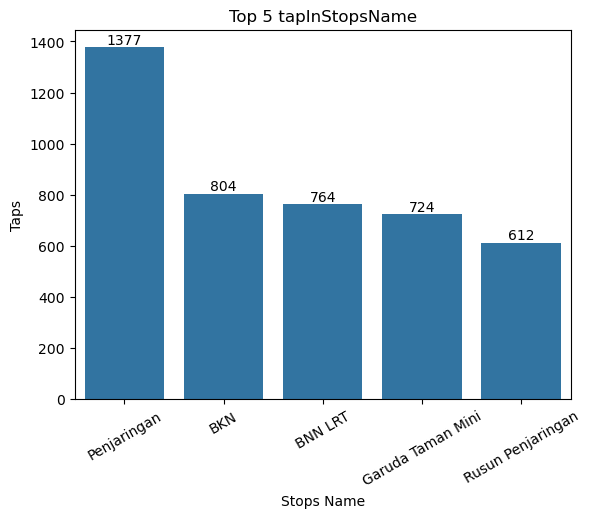

In [33]:
# Show top 5 tap-in stop name
topStop(df_eda, 'tapInStopsName')

The Top 5 Tap-In Stops bar chart shows that Penjaringan is the most used starting point with 1,169 taps, followed by BKN with 655. BNN LRT, Rusun Penjaringan, and Garuda Taman Mini have similar starting usage, each ranging from 544 to 625 taps.

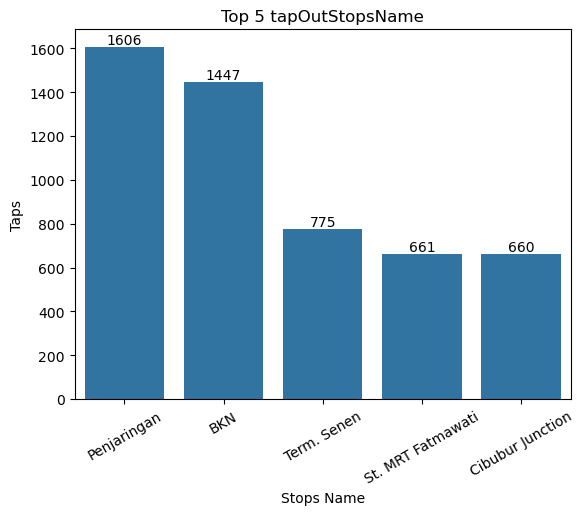

In [34]:
# Show top 5 tap-out stop name
topStop(df_eda, 'tapOutStopsName')

The Top 5 Tap Out Stops bar chart shows that Penjaringan is also the most frequent destination with 1,370 taps, followed by BKN at 1,173. Other popular ending stops include Term. Senen (600), St. MRT Fatmawati (578), and Rusun Penjaringan (555). This indicates that Penjaringan and BKN are the primary hubs for both starting and ending trips.

Correlation

In [35]:
# Calculate the correlation between numerical columns
tjCorrelation = df_eda.corr(numeric_only=True).round(2)

tjCorrelation

,payCardID,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapOutStopsLat,tapOutStopsLon,stopEndSeq,payAmount,custAge,tapInHour,tapOutHour,tapDay,travelDuration
payCardID,1.00,-0.00,-0.00,-0.01,-0.02,-0.01,-0.01,-0.02,-0.01,0.01,0.00,0.00,0.00,-0.00,0.00
payCardBirthDate,-0.00,1.00,-0.00,-0.01,-0.01,-0.01,-0.01,-0.02,-0.00,0.01,-1.00,0.00,0.00,-0.00,-0.00
direction,-0.00,-0.00,1.00,-0.01,0.00,-0.02,-0.05,0.05,-0.01,0.00,0.00,0.03,0.03,0.00,0.01
tapInStopsLat,-0.01,-0.01,-0.01,1.00,0.01,0.00,0.90,0.01,-0.00,-0.17,0.01,-0.00,-0.00,0.00,0.00
tapInStopsLon,-0.02,-0.01,0.00,0.01,1.00,0.04,0.02,0.90,0.06,-0.20,0.01,-0.00,-0.00,0.00,-0.00
stopStartSeq,-0.01,-0.01,-0.02,0.00,0.04,1.00,-0.01,0.04,0.82,-0.25,0.01,-0.01,-0.01,-0.00,-0.01
tapOutStopsLat,-0.01,-0.01,-0.05,0.90,0.02,-0.01,1.00,0.00,-0.01,-0.18,0.01,0.00,0.00,0.00,0.01
tapOutStopsLon,-0.02,-0.02,0.05,0.01,0.90,0.04,0.00,1.00,0.06,-0.20,0.02,0.01,0.01,0.00,0.00
stopEndSeq,-0.01,-0.00,-0.01,-0.00,0.06,0.82,-0.01,0.06,1.00,-0.33,0.00,-0.01,-0.01,0.00,-0.01
payAmount,0.01,0.01,0.00,-0.17,-0.20,-0.25,-0.18,-0.20,-0.33,1.00,-0.01,0.00,0.01,0.00,0.01


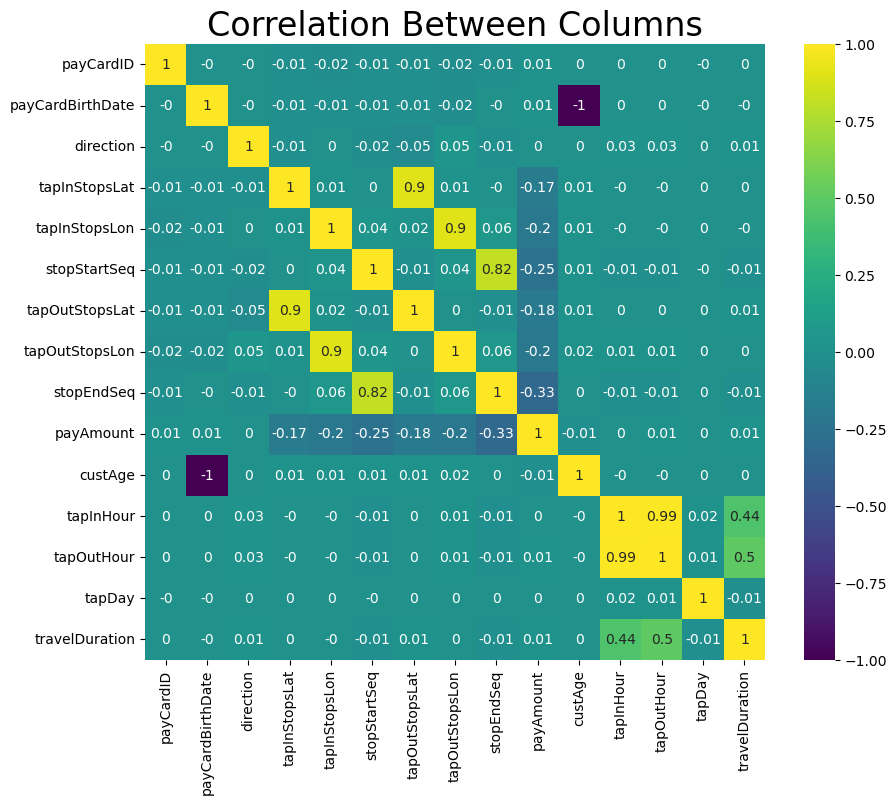

In [36]:
# Show the correlation between numerical columns
def showCorr(data):
    plt.figure(figsize=(10,8))
    sns.heatmap(tjCorrelation, annot=True, cmap='viridis')
    plt.title('Correlation Between Columns', fontsize = 24)
    plt.show()

showCorr(tjCorrelation)

The Correlation Between Columns heatmap shows how different data points relate to each other. There is a very strong relationship between tapInHour and tapOutHour with a score of 0.99, as well as between travelDuration and the tap hours (around 0.44 to 0.5). Location data, like Lat and Lon, also show strong connections between starting and ending points (scores of 0.9 to 0.91). Most other categories, such as payAmount or custAge, show almost no relationship to trip timing or location, with scores near 0.